In [38]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.image as mpimg
from matplotlib.transforms import blended_transform_factory

from highlight_text import ax_text, fig_text
from drawarrow import ax_arrow, fig_arrow
from pyfonts import load_google_font

In [2]:
data_path = os.path.join(
    "..", "data",
    "india_quick.xlsx"
)

data = pd.read_excel(data_path)

data.head()

,Quarter,Zomato - Food Delivery Share of Total Revenue,Zomato - Quick Commerce Share of Total Revenue,Swiggy - Food Delivery Share of Total Revenue,Swiggy - Quick Commerce Share of Total Revenue,Quarter Label,Quarter Index
0,Q4FY22,0.834,0.000,NaN,NaN,Q4,1
1,Q1FY23,0.812,0.000,NaN,NaN,Q1,2
2,Q2FY23,0.750,0.067,NaN,NaN,Q2,3
3,Q3FY23,0.662,0.127,NaN,NaN,Q3,4
4,Q4FY23,0.634,0.150,NaN,NaN,Q4,5


In [3]:
data["Quarter"].iloc[-1]

'Q4FY26'

In [4]:
# Color Customizations

# Common
grey = "#6c757d"
bg = "white"

# Zomato
z_colors = {
    "z_food":"#780000",
    "z_quick":"#ffb703"
}

# Swiggy
s_colors = {
    "s_food":"#ff6700",
    "s_quick":"#0466c8"
}


# Font Customizations

fonts = {
    "main":load_google_font("Noto Serif", weight=600),
    "italic":load_google_font("Noto Serif", italic=True),
    "bold":load_google_font("Noto Serif", weight=800),
    "bold_italic":load_google_font("Noto Serif", weight=600, italic=True)
}

In [55]:
# Title
title = """
        <Quick Commerce> Overtakes Food Delivery
        """

# Subtitle
subtitle = """
        A structural shift in India’s food-tech revenue mix
        """




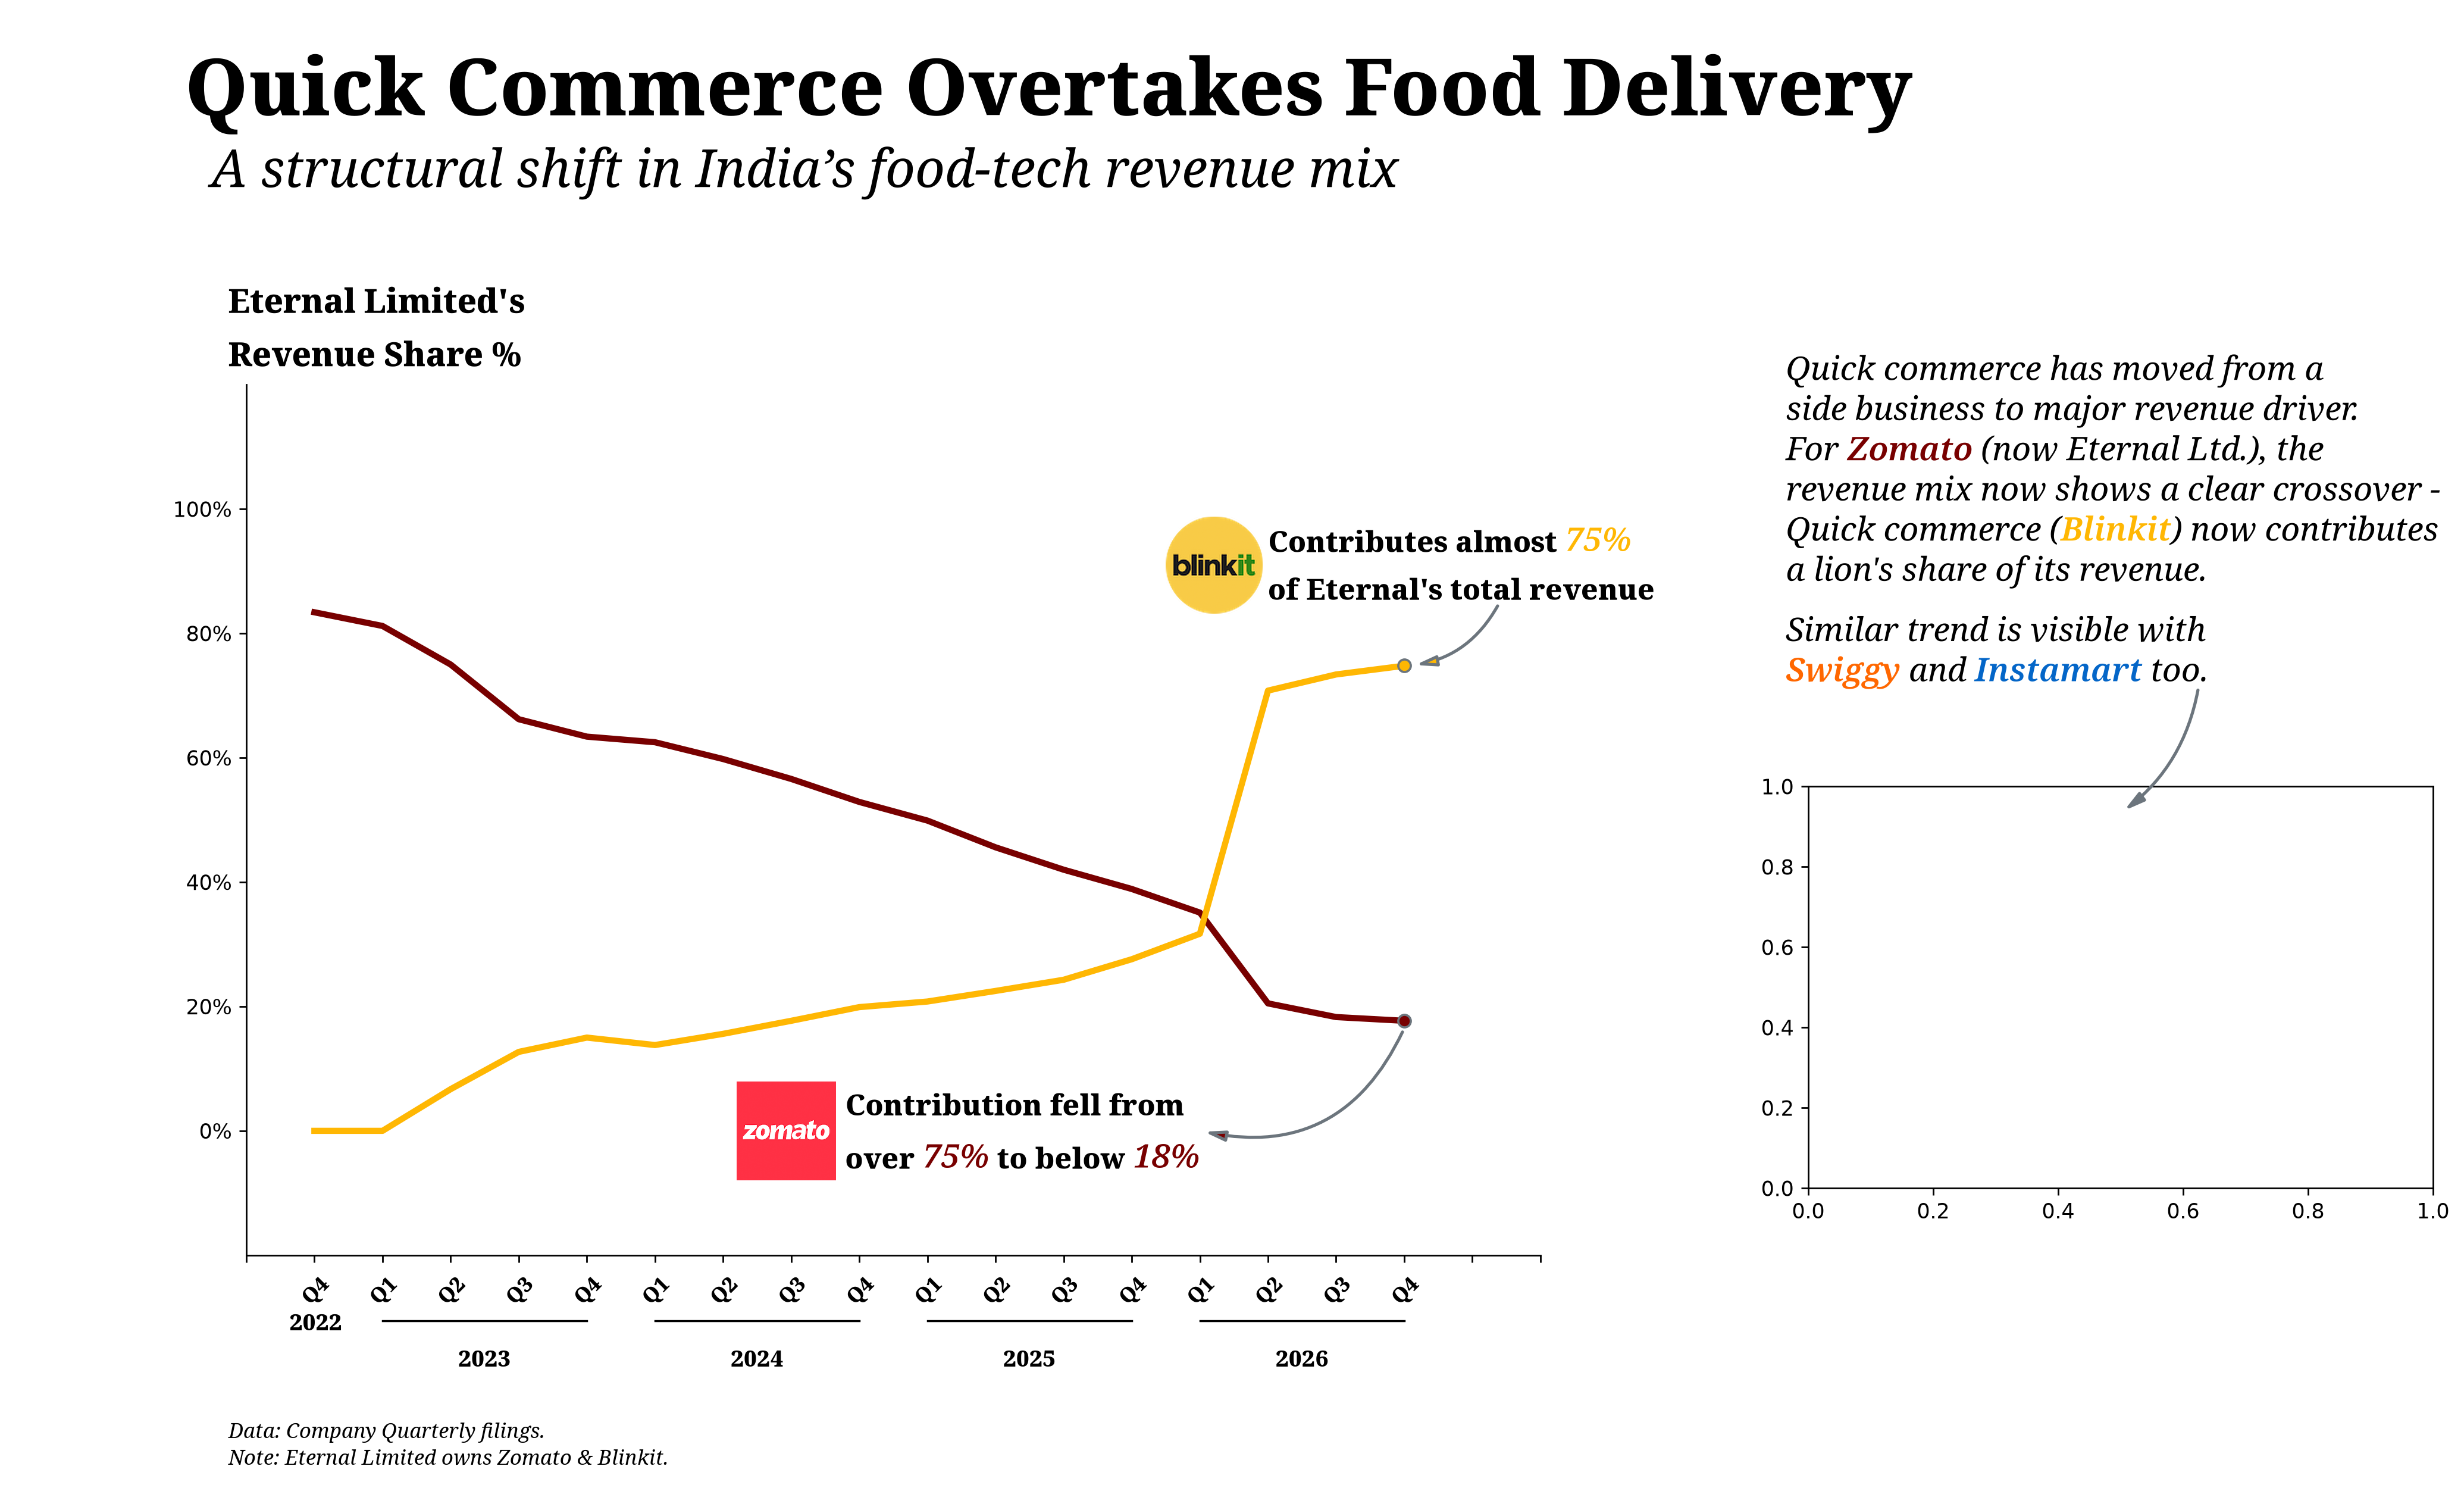

In [105]:
# -----------------------------
# Figure
# -----------------------------
fig = plt.figure(figsize=(15, 9), facecolor=bg, dpi=250)

# -----------------------------
# Axes layout
# [left, bottom, width, height]
# -----------------------------
ax_zomato = fig.add_axes([0.1, 0.02, 0.58, 0.65])
ax_swiggy = fig.add_axes([0.8, 0.07, 0.28, 0.3])

ax_zomato.set_facecolor(bg)
ax_zomato.spines[["top", "right"]].set_visible(0)

# -----------------------------
# Title + subtitle
# -----------------------------
fig_text(
    x=0.0, y=0.94,
    s=title,
    fontsize=38,
    font=fonts["bold"],
    highlight_textprops=[dict(font=fonts["bold"])]
)

fig_text(
    x=0.035, y=0.865,
    s=subtitle,
    fontsize=25,
    font=fonts["italic"]
)


# -----------------------------
# Zomato chart
# -----------------------------
ax_zomato.plot(
    data["Quarter Index"],
    data["Zomato - Food Delivery Share of Total Revenue"],
    linewidth=3,
    color=z_colors["z_food"]
)

ax_zomato.plot(
    data["Quarter Index"],
    data["Zomato - Quick Commerce Share of Total Revenue"],
    linewidth=3,
    color=z_colors["z_quick"]
)

# ax_zomato.set_title("Zomato | Share of Revenue (%)", loc="left", fontsize=13, font=fonts["main_head"])
fig_text(
    x=0.092, y=0.75,
    s="Eternal Limited's\nRevenue Share %",
    fontsize=16,
    font=fonts["bold"]
)
# ax_zomato.set_ylabel("Share of revenue (%)", font=fonts["main_head"])
ax_zomato.tick_params(axis="x", rotation=45)

# last points
last_quarter = data["Quarter Index"].iloc[-1]
last_food_share = data["Zomato - Food Delivery Share of Total Revenue"].iloc[-1]
last_quick_share = data["Zomato - Quick Commerce Share of Total Revenue"].iloc[-1]


# line-end labels

# ax_zomato.grid()
ax_zomato.set_xlim(0,19)
ax_zomato.set_xticks(ticks=range(0,20,1), labels=range(0,20,1))


yticks = np.arange(0, 1.01, 0.2)

ax_zomato.set_ylim(-0.2, 1.2)
ax_zomato.set_yticks(
    ticks=yticks,
    labels=[f"{int(y*100)}%" for y in yticks]
)



xticks = np.arange(0, 20)

xtick_labels = [
    "" if x in [0, 18, 19] else data.loc[data["Quarter Index"] == x, "Quarter Label"].iloc[0]
    for x in xticks
]

ax_zomato.set_xticks(
    ticks=xticks,
    labels=xtick_labels,
    font=fonts["bold"]
)



# -----------------------------
# Blinkit callout
# -----------------------------

blinkit_logo = mpimg.imread(os.path.join("..", "data", "blinkit.png"))

imagebox = OffsetImage(
    blinkit_logo,
    zoom=0.5,              # adjust as required
    interpolation="lanczos"
)

ab = AnnotationBbox(
    imagebox,
    (13.5, 0.91),   # data coordinates
    frameon=False,
    box_alignment=(0, 0.5),            # left-center of logo
    zorder=10
)

ax_zomato.add_artist(ab)

ax_text(
    x=15,
    y=0.915,
    s="Contributes almost <75><%>\nof Eternal's total revenue",
    ax=ax_zomato,
    font=fonts["bold"],
    fontsize=14,
    ha="left",
    va="center",
    highlight_textprops=[
        dict(font=fonts["bold_italic"], color=z_colors["z_quick"], fontsize=16),
        dict(font=fonts["bold_italic"], color=z_colors["z_quick"], fontsize=16)
        ]
)
ax_arrow(
    tail_position=(18.4, 0.85),
    head_position=(last_quarter+0.1, last_quick_share),
    radius=-0.25, head_width=2, ax=ax_zomato,
    facecolor=z_colors["z_quick"], edgecolor=grey, width=1.5
)
ax_zomato.scatter([17, 17], [last_quick_share,last_quick_share],
                  zorder=5, marker="o",
                  color=z_colors["z_quick"], edgecolors=grey)



# -----------------------------
# Zomato callout
# -----------------------------

zomato_logo = mpimg.imread(os.path.join("..", "data", "zomato.png"))

imagebox_z = OffsetImage(
    zomato_logo,
    zoom=0.2,              # adjust as required
    interpolation="lanczos"
)

ab_z = AnnotationBbox(
    imagebox_z,
    (7.2, 0),   # data coordinates
    frameon=False,
    box_alignment=(0, 0.5),            # left-center of logo
    zorder=10
)

ax_zomato.add_artist(ab_z)

ax_text(
    x=14,
    y=0,
    s="Contribution fell from\nover <75%> to below <18%>",
    ax=ax_zomato,
    font=fonts["bold"],
    fontsize=14,
    ha="right",
    va="center",
    highlight_textprops=[
        dict(font=fonts["bold_italic"], color=z_colors["z_food"], fontsize=16),
        dict(font=fonts["bold_italic"], color=z_colors["z_food"], fontsize=16)
        ]
)
ax_zomato.scatter([17, 17], [last_food_share,last_food_share],
                  zorder=5, marker="o",
                  color=z_colors["z_food"], edgecolors=grey)
ax_arrow(
    tail_position=(17, last_food_share-0.012),
    head_position=(14, 0),
    radius=-0.4, head_width=2, ax=ax_zomato,
    facecolor=z_colors["z_food"], edgecolor=grey, width=1.5
)




fig_text(
    x=0.1195, y=-0.0179,
    s="2022",
    fontsize=11,
    font=fonts["bold"]
)

years = {
    "2023": (2, 5),
    "2024": (6, 9),
    "2025": (10, 13),
    "2026": (14, 17)
}

trans = blended_transform_factory(ax_zomato.transData, ax_zomato.transAxes)

for year, (x0, x1) in years.items():
    ax_zomato.plot(
        [x0, x1], [-0.075, -0.075],
        transform=trans,
        color="black",
        lw=1,
        clip_on=False
    )

    ax_zomato.text(
        (x0 + x1) / 2,
        -0.1,
        year,
        transform=trans,
        ha="center",
        va="top",
        fontsize=11,
        font=fonts["bold"]
    )

fig_text(
    x=0.092, y=-0.1,
    s="Data: Company Quarterly filings.",
    fontsize=10,
    font=fonts["italic"]
)
fig_text(
    x=0.092, y=-0.12,
    s="Note: Eternal Limited owns Zomato & Blinkit.",
    fontsize=10,
    font=fonts["italic"]
)

# -----------------------------
# -----------------------------
# -----------------------------



# -----------------------------
# Story text
# -----------------------------

# Data story
data_story = """
        Quick commerce has moved from a side business\n
        to a major revenue engine.\n
        For Zomato (<now Eternal Ltd.>), the revenue mix now shows a clear\n
        crossover: quick commerce has overtaken food delivery.\n\n
        A similar trend is visible with <Swiggy> as well.
        """

ds_1 = "Quick commerce has moved from a"
ds_2 = "side business to major revenue driver."
ds_3 = "For <Zomato> (now Eternal Ltd.), the"
ds_4 = "revenue mix now shows a clear crossover -"
ds_5 = "Quick commerce (<Blinkit>) now contributes"
ds_6 = "a lion's share of its revenue."
ds_7 = "Similar trend is visible with"
ds_8 = "<Swiggy> and <Instamart> too."

x_story = 0.79
y_story = 0.7
y_story_diff = 0.03
fig_text(
    x=x_story, y=y_story, s=ds_1,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[]
)
fig_text(
    x=x_story, y=y_story-y_story_diff, s=ds_2,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[]
)
fig_text(
    x=x_story, y=y_story-y_story_diff*2, s=ds_3,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[dict(color=z_colors["z_food"], font=fonts["bold_italic"])]
)
fig_text(
    x=x_story, y=y_story-y_story_diff*3, s=ds_4,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[]
)
fig_text(
    x=x_story, y=y_story-y_story_diff*4, s=ds_5,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[dict(color=z_colors["z_quick"], font=fonts["bold_italic"])]
)
fig_text(
    x=x_story, y=y_story-y_story_diff*5, s=ds_6,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[]
)
fig_text(
    x=x_story, y=y_story-y_story_diff*6.5, s=ds_7,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[]
)

fig_text(
    x=x_story, y=y_story-y_story_diff*7.5, s=ds_8,
    font=fonts["italic"], fontsize=16, fig=fig,
    highlight_textprops=[
        dict(color=s_colors["s_food"], font=fonts["bold_italic"]),
        dict(color=s_colors["s_quick"], font=fonts["bold_italic"])]
)
fig_arrow(
    tail_position=(0.975, 0.445), head_position=(0.94, 0.35),
    head_width=2, fig=fig, radius=-0.2, 
    facecolor=grey, edgecolor=grey, width=1.5
)

# -----------------------------
# Swiggy chart
# -----------------------------
# ax_swiggy.plot(
#     data["Quarter Index"],
#     data["Swiggy - Food Delivery Share of Total Revenue"],
#     linewidth=2,
#     color=s_colors["s_food"]
# )

# ax_swiggy.plot(
#     data["Quarter Index"],
#     data["Swiggy - Quick Commerce Share of Total Revenue"],
#     linewidth=2,
#     color=s_colors["s_quick"]
# )

# ax_swiggy.set_title("Swiggy | Share of Revenue (%)", loc="left", fontsize=10, font=fonts["main"])
# ax_swiggy.tick_params(axis="x", rotation=45, labelsize=7)
# ax_swiggy.tick_params(axis="y", labelsize=7)

save_path = os.path.join(
    "..", "viz",
    "test_2.jpeg"
)

plt.savefig(save_path, dpi=350, bbox_inches="tight", pad_inches=0.5)
